In [5]:
import numpy as np
import matplotlib.pyplot as plt

from cavity import Cavity
from simulation import Cavity_simulation
from bandstructure_class import BandStructureSim

import tidy3d as td
C0 = td.constants.C_0

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

directory = "cavity_tutorial"
save_name = "cavity_tutorial_simulation"


---
## Finding geometries that are useful for the central defect and the mirror

We need to find a geometry for a unitcell that has the frequency of interest at the center of the bandgap. This unitcell will be used as the mirror cell. 

Then we need to find a geometry for which the frequency of interest intersect the lower (upper) band to create a dielectric (air) defect that sustains the central mode. 

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 160 x 80.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 10, 0)
     (0, 0, 5)
Cell volume = 50
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.1, -0)
     (0, -0, 0.2)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,2,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.5,0.5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -5.0625..5.0625, -2.5625..2.5625)
          bounding box (-0.25..0.25, -0.25..0.25, -5e+19..5e+19)
          shift object by (0, 0, -5)
          ellipsoid, center = (0,0,0)
               size (0.5,0.5,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding box (-0.25..0.25, -0.25..0.25, -5e+19..5e+19)
          shift object by (0, 

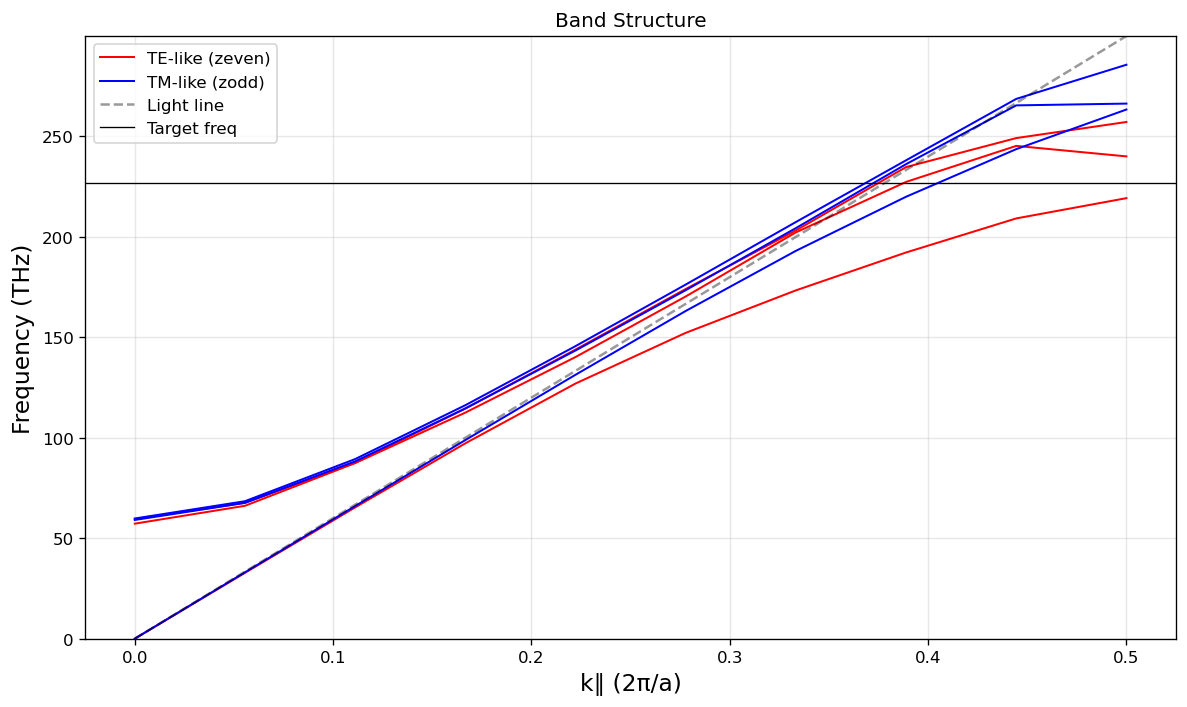

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 175 x 90.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 10.6383, 0)
     (0, 0, 5.31915)
Cell volume = 56.5867
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.094, -0)
     (0, -0, 0.188)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,2.12766,0.531915)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.531915,0.531915,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -5.37994..5.37994, -2.71868..2.71868)
          bounding box (-0.265957..0.265957, -0.265957..0.265957, -5e+19..5e+19)
          shift object by (0, 0, -5.31915)
          ellipsoid, center = (0,0,0)
               size (0.531915,0.531915,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding

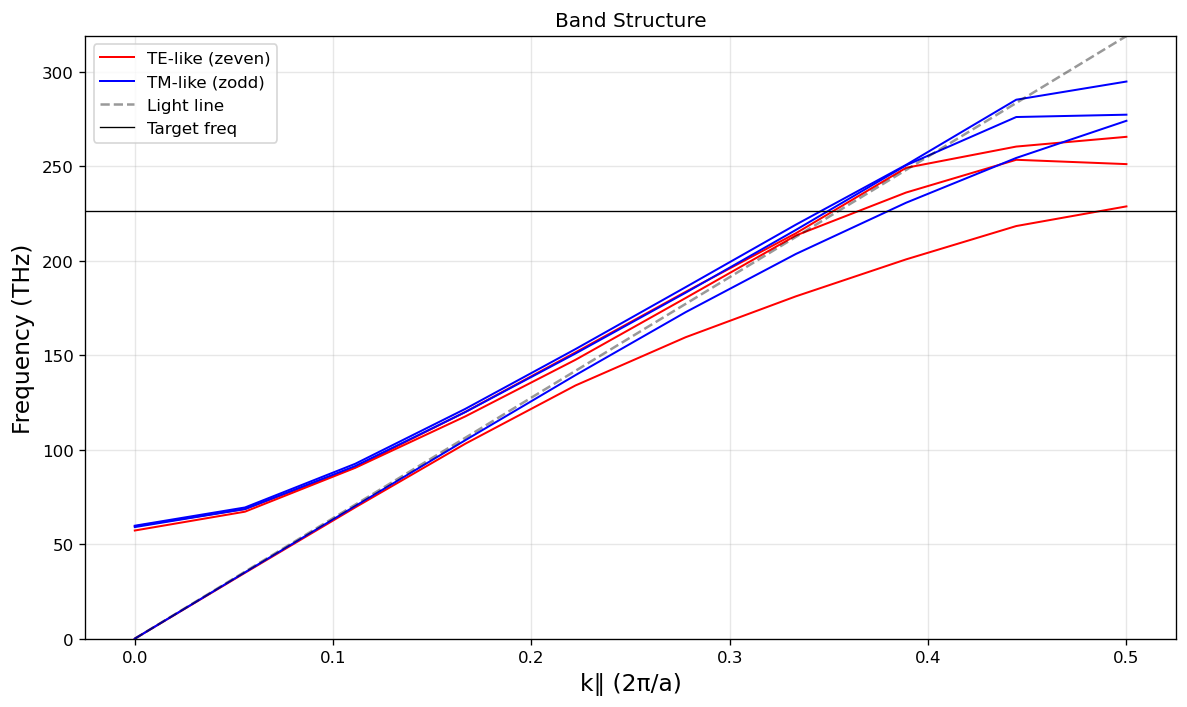

(<Figure size 1200x720 with 1 Axes>,
 <Axes: title={'center': 'Band Structure'}, xlabel='k∥ (2π/a)', ylabel='Frequency (THz)'>)

In [6]:
thickness = 0.25
wl0 = 1.324
freq0 = C0 / wl0


Lx = 0.5
Ly = 1
dx = 0.25
dy = 0.25

sim = BandStructureSim(
    Lx=Lx, Ly=Ly, thickness=thickness,
    geometry="ellipse", hole_params=[dx, dy],
    material_index=2.0, num_bands=3, resolution=16,
)
sim.run_bandstructure(k_min=0, k_max=0.5, n_k=8)
sim.plot_bands(units='THz', freq0_Hz=freq0)


Lx = 0.47
Ly = 1
dx = 0.25
dy = 0.25

sim = BandStructureSim(
    Lx=Lx, Ly=Ly, thickness=thickness,
    geometry="ellipse", hole_params=[dx, dy],
    material_index=2.0, num_bands=3, resolution=16,
)
sim.run_bandstructure(k_min=0, k_max=0.5, n_k=8)
sim.plot_bands(units='THz', freq0_Hz=freq0)

---
## Creating a Cavity with Custom Parameters

You can control three dictionaries:
- **`n_cells`** — number of cells per section (left taper, left mirror, defect, right mirror, right taper)
- **`parameters`** — lattice constants and hole dimensions for each section
- **`context`** — physical settings (frequency, thickness, width, medium, polarization, hole geometry, etc.)

Below we define a cavity with an intentional defect: the defect region has a smaller lattice constant and smaller holes to create a photonic-crystal bandgap defect mode.

Each section (linear taper, mirror or defect) of the nanobeam cavity is created such that the edge cells of the given section matches exactly the edge cels of the adjacent sections. For example:
- the leftmost cell of the defect matches the rightmost cell of the left mirror
- the righmost cell of the defect matches the leftmost cell of the right mirror
- the rightmost cell of the left linear taper matches the leftmost cell of the left mirror
- the leftmost cell of the right linear taper matches the rightmost cell of the right mirror

This means that if one does not want to simulate the taper, you can just set the number to 1 and it will just be an additional cell or the mirror. Or if one does not want to simulate a mirror, you can just set the number of mirror to 1 and it will match the last cell of the defect. At the moment the code cannot handle sections with zero components so the edge case is the following: 

```python
n_cells = {
    "N_left_taper":    1,
    "N_left_mirror":  1,
    "N_defect":       2,   
    "N_right_mirror": 1,
    "N_right_taper":   1,
}
```

The central defect cannot have less than 2 cells at the moment. 

This edge case is mostly due to small indexing problem in how the sections are created. 

In [7]:
n_cells = {
    "N_left_taper":    5,
    "N_left_mirror":  10,
    "N_defect":       30,   # odd → includes a central cell
    "N_right_mirror": 20,
    "N_right_taper":   1,
}

parameters = {
    "parameters_taper_left":    {"lattice": 0.48, "hole_params": np.array([0.01, 0.01])},
    "parameters_mirrors_left":  {"lattice": 0.5, "hole_params": np.array([0.25, 0.25])},
    "parameters_defect":        {"lattice": 0.47,  "hole_params": np.array([0.25, 0.25])},
    "parameters_mirrors_right": {"lattice": 0.5, "hole_params": np.array([0.25, 0.25])},
    "parameters_taper_right":   {"lattice": 0.48, "hole_params": np.array([0.01, 0.01])},
}

wavelength = 1.324
freq0 = C0 / wavelength
fwidth = freq0 * 0.01

context = {
    "freq0":          freq0,       # centre frequency (1/µm)
    "fwidth":         fwidth,        # bandwidth
    "thickness":      0.25,       # slab thickness (µm)
    "width":          1,       # waveguide width (µm)
    "polarization":   "Ey",       # dipole polarization (TE-like)
    "medium":         2.0,          # material name (file-based dispersion) or refractive index
    "mode":           "dielectric",
    "sidewall_angle":  0,
    "geometry":       "ellipse",  # hole shape: 'ellipse' or 'square'
}

cavity = Cavity(n_cells=n_cells, parameters=parameters, context=context)

---
## How to choose the linear tapering? 

The last unitcell in the taper should be chosen such that you match the Bragg condition from the waveguide. As put in the Supp of [https://doi.org/10.1103/PhysRevLett.129.053603](https://doi.org/10.1103/PhysRevLett.129.053603): 

"The final lattice constant before the waveguide is chosen to match the periodicity of the standing wave formed by the incoming and reflected light as set by the effective refractive index of the waveguide and the optical frequency of the mode. In choosing this lattice constant, we aim to have the electric field nodes centered on the holes, so that the incident electric field is initially minimum when encountering an interface, thereby reducing scattering. The complementary view from the perspective of the outgoing cavity light is that the smooth reduction of these holes and the decreasing lattice constant effectively pushes the mode back into the dielectric band before closing the gap entirely."

Therefore the code finds out the n_effective of the waveguide and find the periodicity of the Bragg condition. Then you should linear taper with smaller holes with that specific perioditcity to close the bandgap. 

```python
n_eff = mode_data.n_eff.values.flatten()
k_wg = 2 * np.pi * n_eff * self.context["freq0"] / C0
a_last = self.wl0 / (2 * n_eff)
```

---
## Building the FDTD Simulation

`build_simulation()` performs several steps:
1. Resolves the material (dispersion fitting or constant index)
2. Computes the simulation domain and PML boundaries
3. Places the point-dipole source and all monitors
4. Constructs the nanobeam geometry (waveguide + holes)
5. Runs a cross-sectional mode solve to find the effective index

You can pass `plot=True` to visualize intermediate steps (dispersion fit, mode solve).

### You can simulate the badstructure of a geometry with tidy3d instead of unsing mbp 

21:07:01 PDT WARNING: Use the remote mode solver with subpixel averaging for    
             better accuracy through 'tidy3d.web.run(...)' or the deprecated    
             'tidy3d.plugins.mode.web.run(...)'.                                

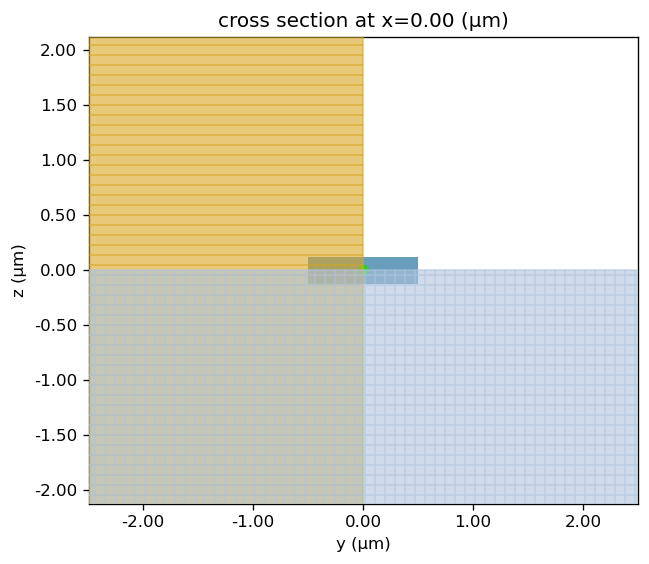

                         wavelength     n eff  k eff  TE (Ey) fraction  \
f            mode_index                                                  
2.264293e+14 0                1.324  1.455148    0.0          0.992163   

                         wg TE fraction  wg TM fraction  mode area  
f            mode_index                                             
2.264293e+14 0                 0.864936        0.804868   0.458768  


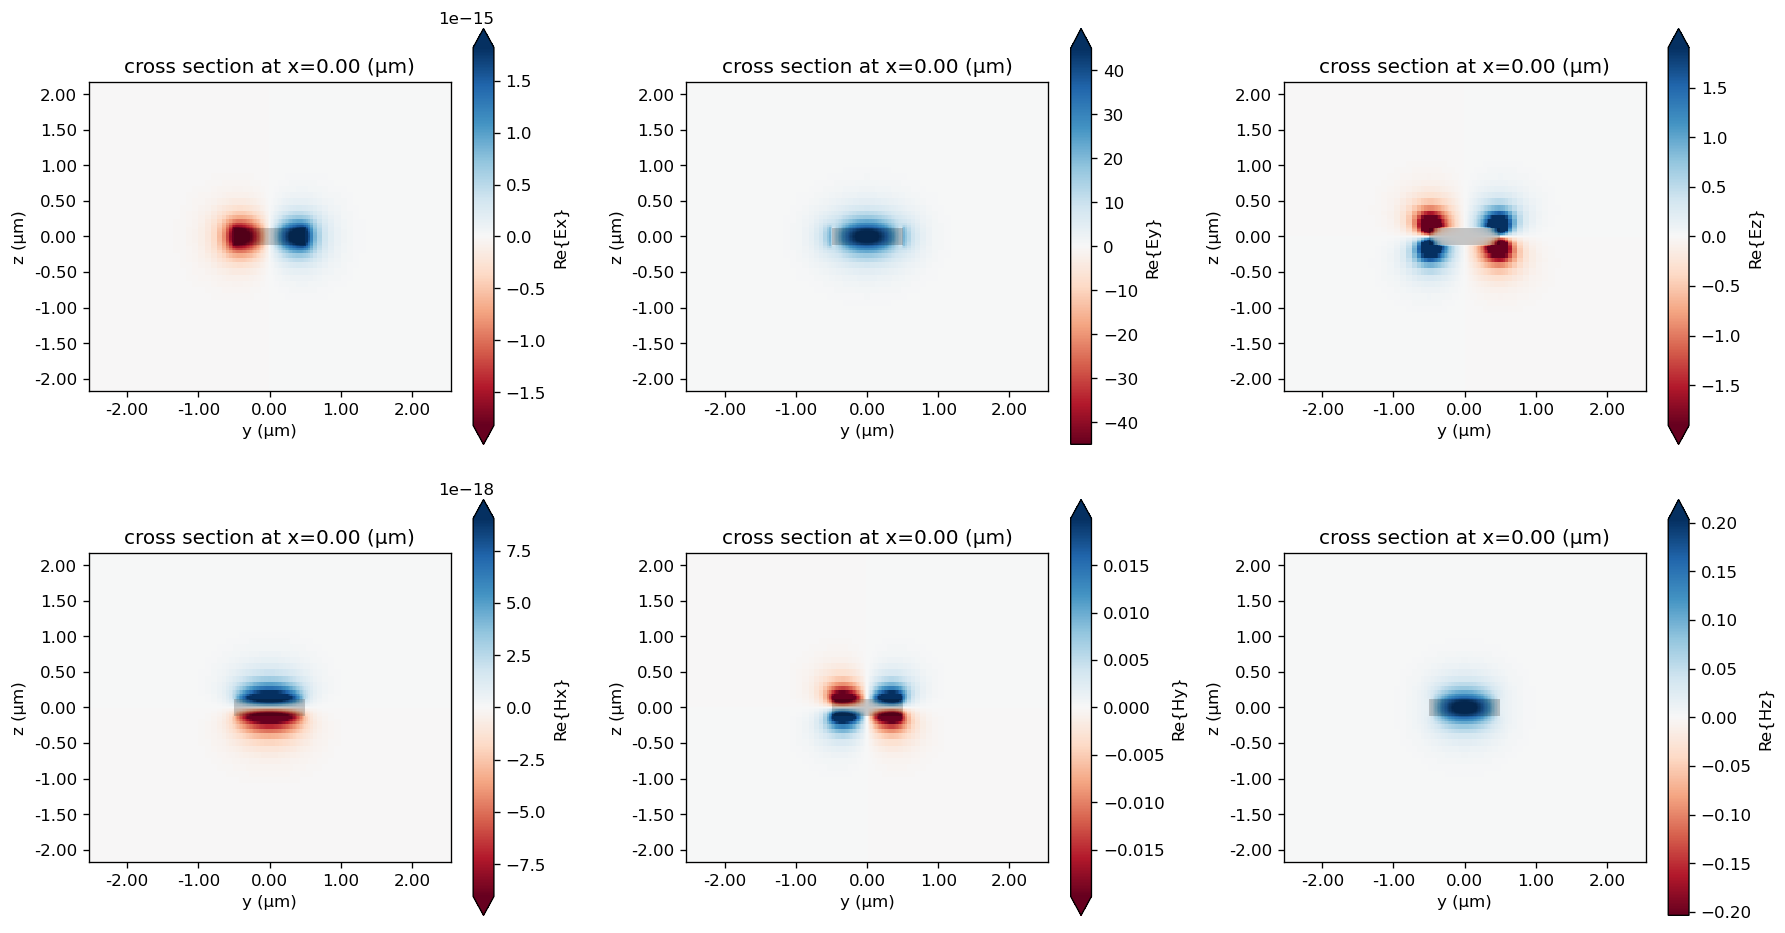

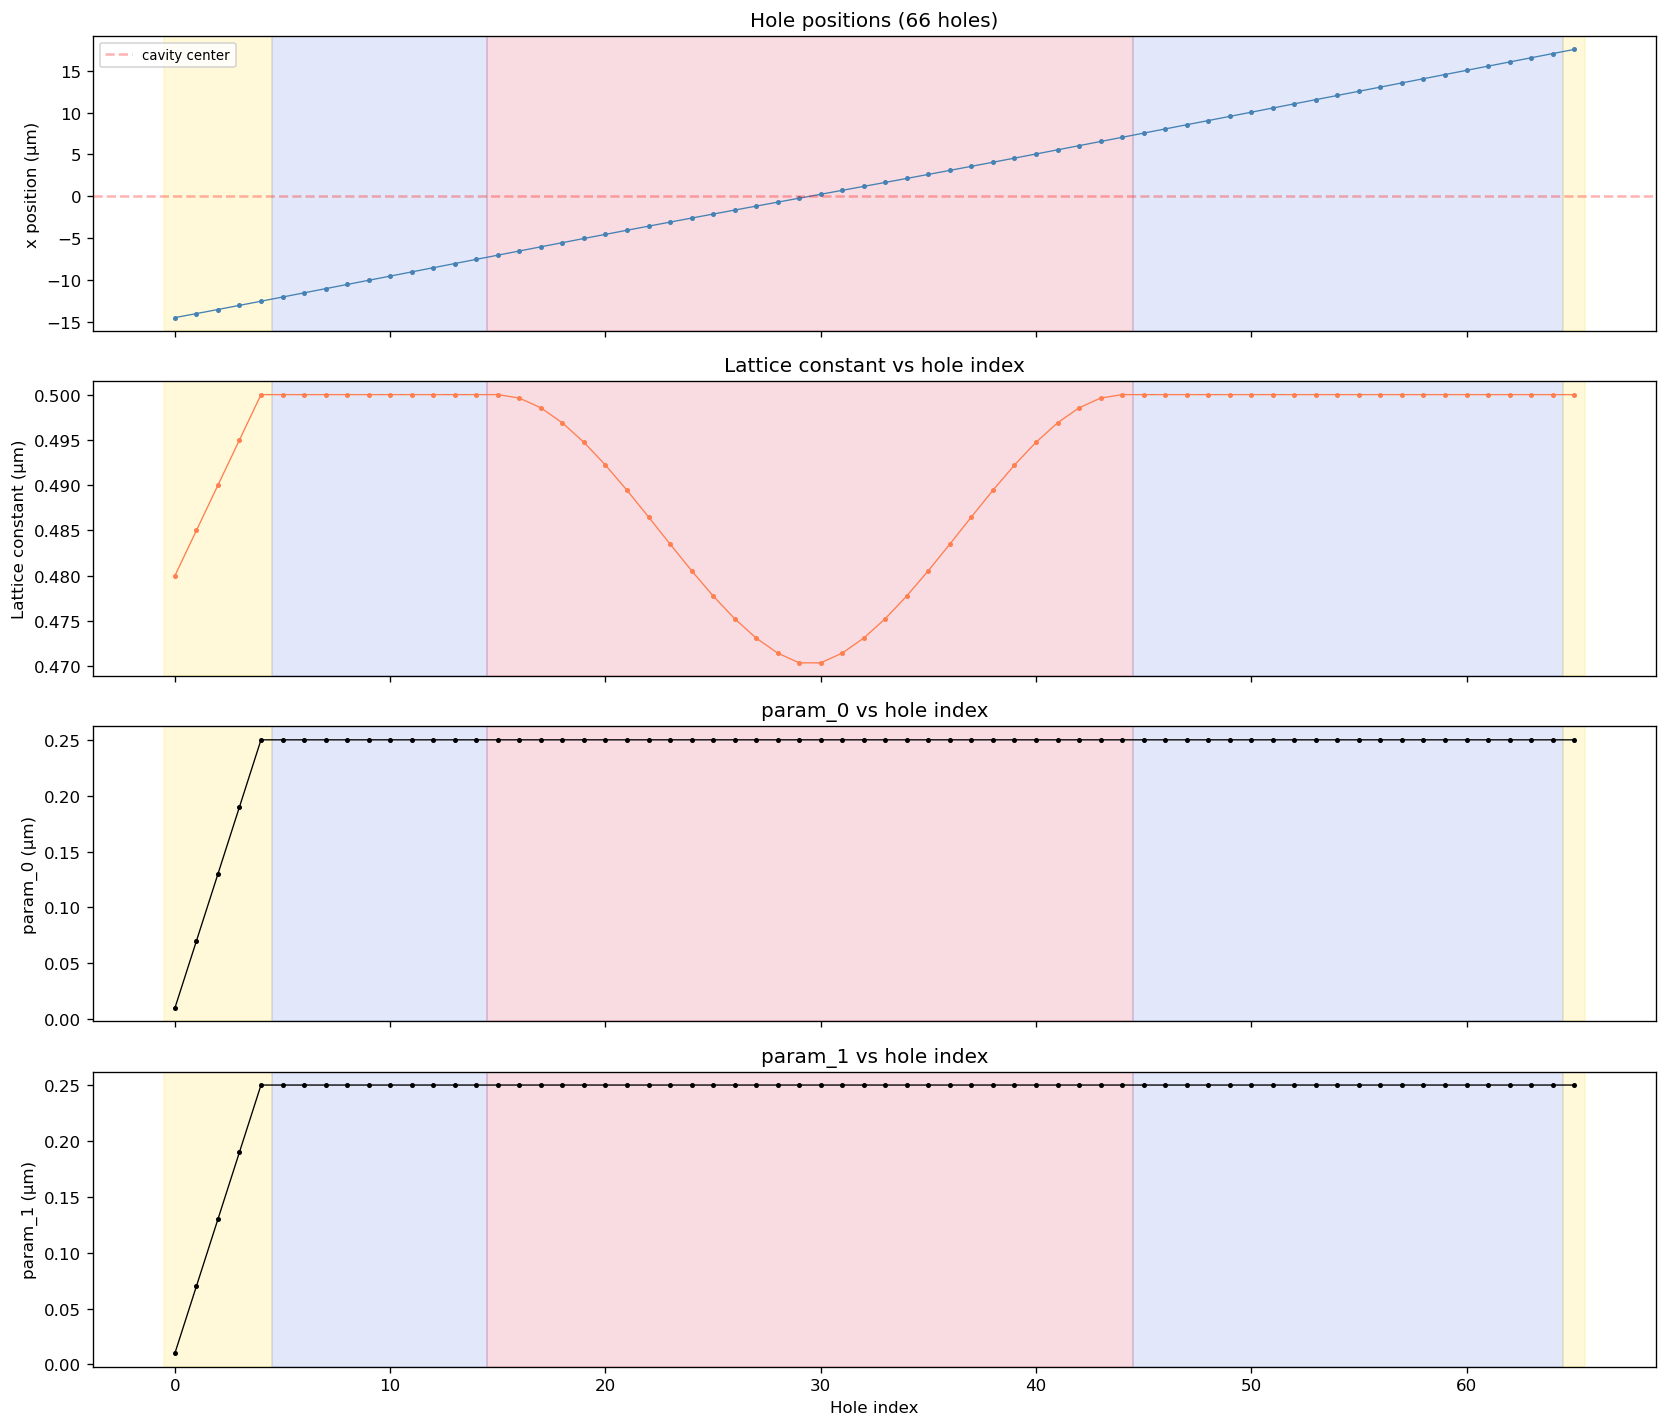

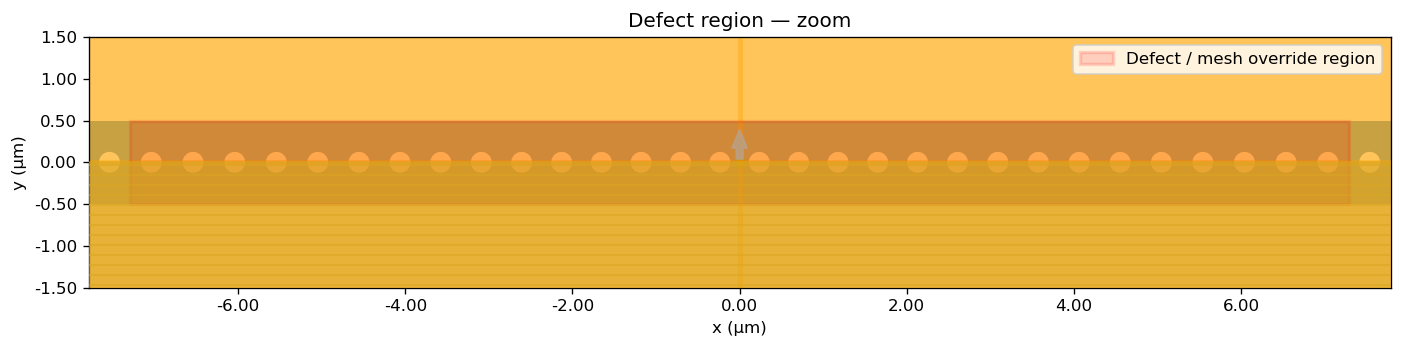

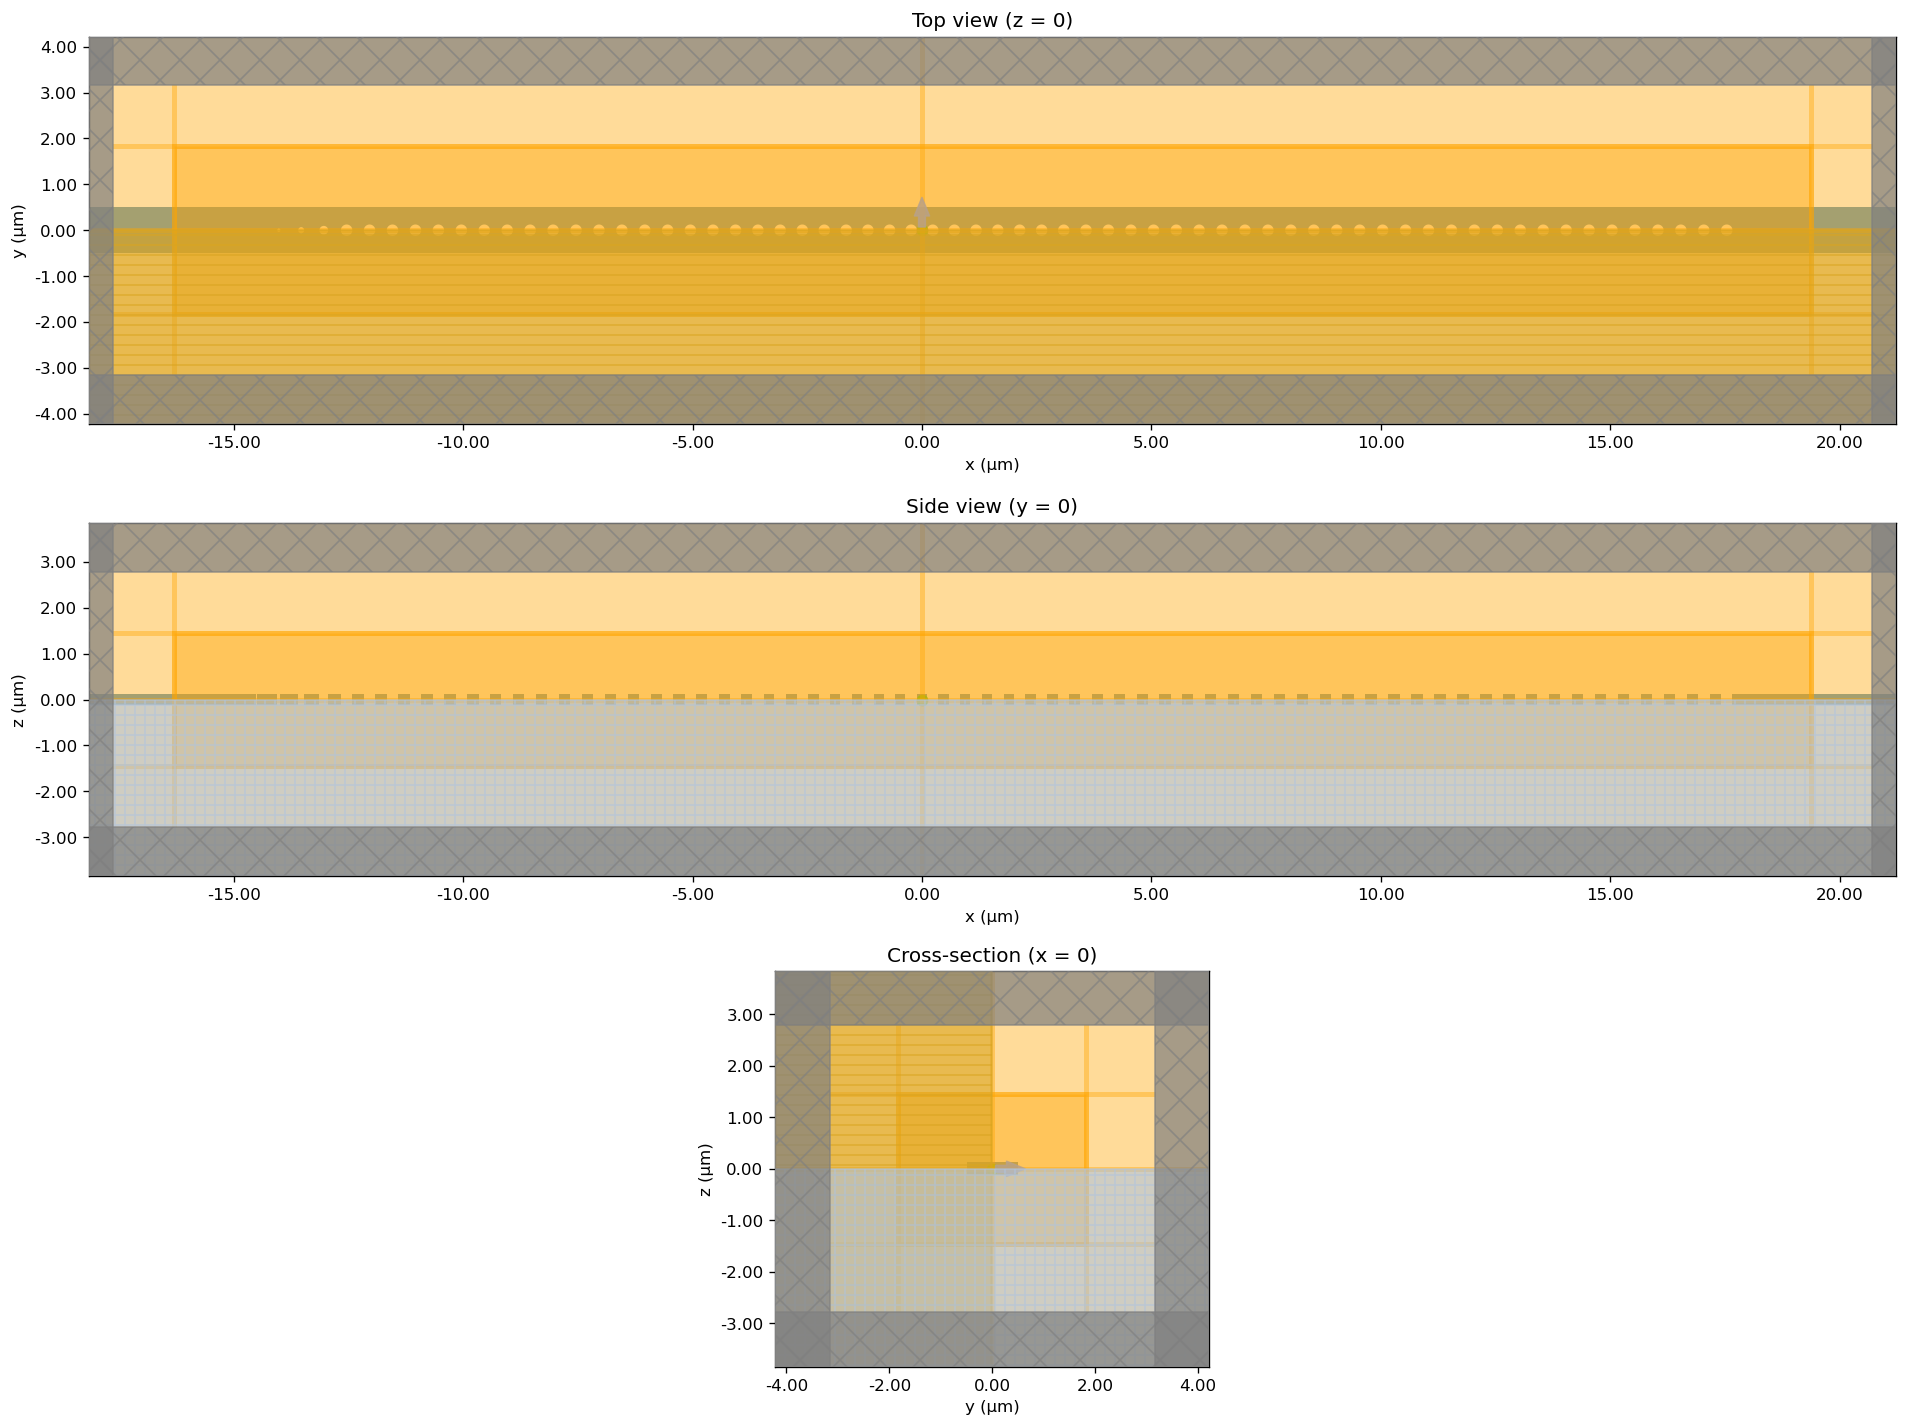

mode n_eff: [1.45514805]
mode k_wg: [6.90556258]
mode a_last: [0.45493653]


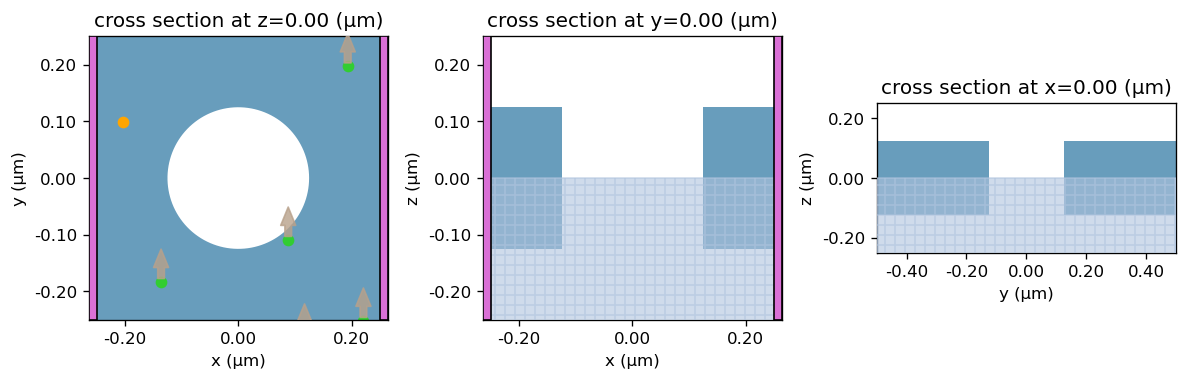

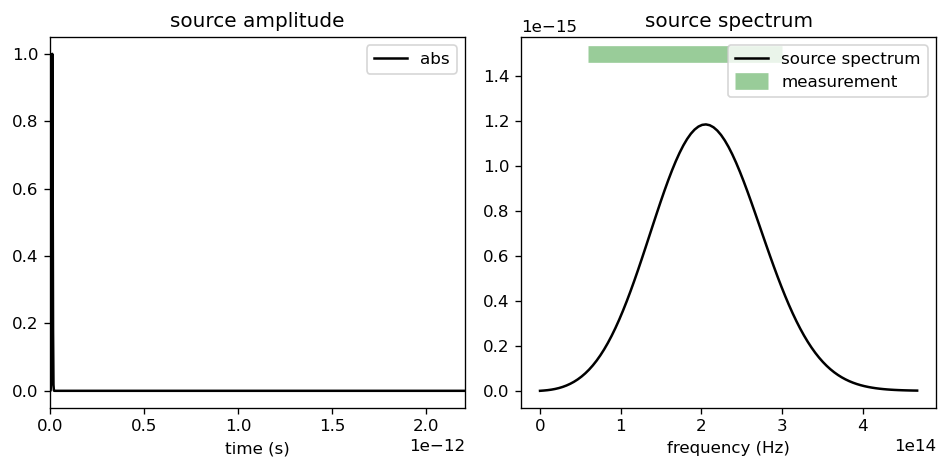

Output()

21:07:05 PDT Started working on Batch containing 9 tasks.

21:07:10 PDT Maximum FlexCredit cost: 0.225 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

21:07:12 PDT Batch complete.

Output()

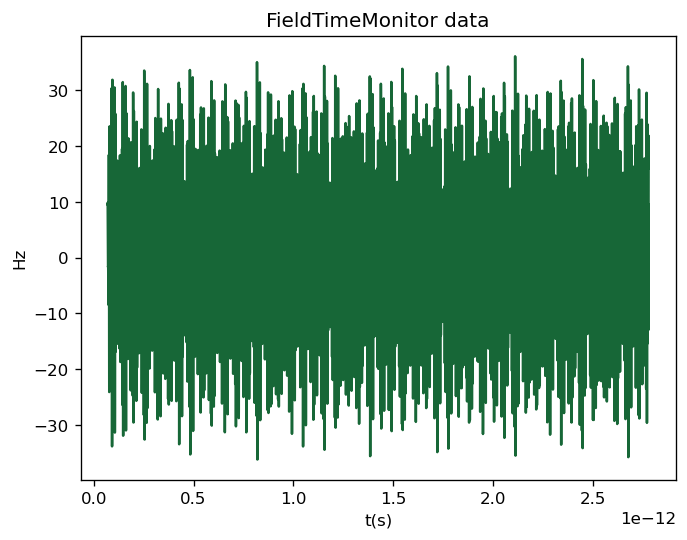

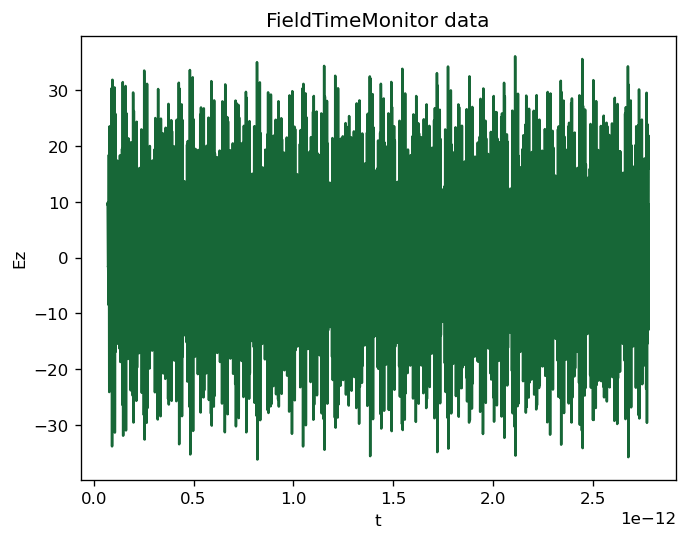

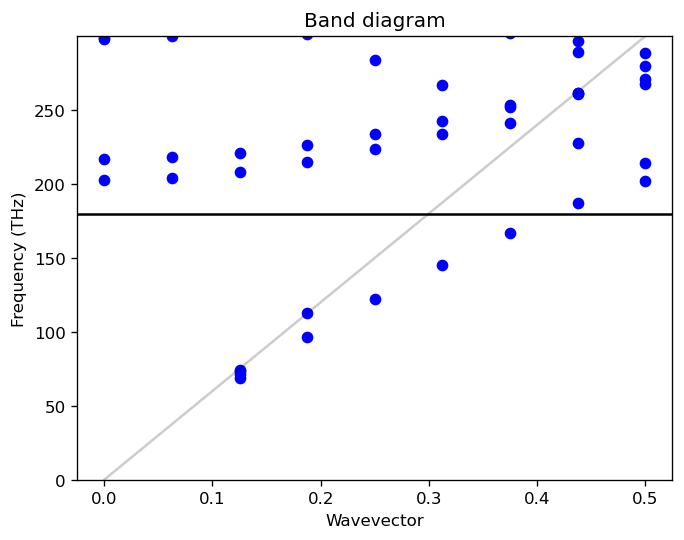

In [8]:
sim = cavity.build_simulation(
    grid_size_override=(0.02, 0.02, 0.02),  # coarser mesh for quick testing
    num_modes=1,
    plot=True,  # show mode solve results
)
sim.plot_simulation()

print("mode n_eff:", sim.n_eff)
print("mode k_wg:", sim.k_wg)
print("mode a_last:", sim.a_last)

bandstructure_tidy = sim.bandstructure_tidy(
    directory=directory,
    save_name=f"{save_name}_bandstructure_mirror_left",
    context=context,
    parameters=parameters["parameters_mirrors_left"],
    plot=True,
)

---
## Running the Simulation on Tidy3D Cloud

The `run()` method uploads and runs the simulation on Tidy3D's cloud servers. You need a valid Tidy3D API key configured.

```python
import tidy3d.web as web
web.configure("YOUR_API_KEY")  # one-time setup
```

In [9]:
sim.upload(directory=directory, save_name=save_name)
sim.estimate_cost()
sim_data = sim.run(directory=directory, save_name=save_name)

21:07:27 PDT Created task 'cavity_tutorial_simulation' with task_id             
             'fdve-9b016dc6-a63e-408d-b427-f59d9b7bb5d6' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=36283;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9b016dc6-a63e-408d-b427-f59d9b7bb5d6\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=386189;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9b016dc6-a63e-408d-b427-f59d9b7bb5d6\taskId]8;;\]8;id=36283;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9b016dc6-a63e-408d-b427-f59d9b7bb5d6\=]8;;\]8;id=939203;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9b016dc6-a63e-408d-b427-f59d9b7bb5d6\fdve]8;;\]8;id=36283;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9b016dc6-a63e-408d-b427-f59d9b7bb5d6\-9b016dc6-a63]8;;\
             ]8;id=36283;https://tidy3d.simulation.cloud/workbench?taskId=fdve-9b016dc6-a63e-408d-b427-f59d9b7bb5d6\e-408d-b427-f59d9b7bb5d6']8;;\.

             Task folder: ]8;id=143595;https://tidy3d.simulation.cloud/folders/folder-b95c5a02-f7e0-4872-843e-dabedcf06b5e\'cavity_tutorial']8;;\.

Output()

21:07:28 PDT Maximum FlexCredit cost: 0.217. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

21:09:46 PDT status = success

21:09:48 PDT View simulation result at                                          
             ]8;id=138424;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c54a45a5-7c44-4a86-8efa-4f4ee50f5f17\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=174305;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c54a45a5-7c44-4a86-8efa-4f4ee50f5f17\taskId]8;;\]8;id=138424;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c54a45a5-7c44-4a86-8efa-4f4ee50f5f17\=]8;;\]8;id=852667;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c54a45a5-7c44-4a86-8efa-4f4ee50f5f17\fdve]8;;\]8;id=138424;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c54a45a5-7c44-4a86-8efa-4f4ee50f5f17\-c54a45a5-7c4]8;;\
             ]8;id=138424;https://tidy3d.simulation.cloud/workbench?taskId=fdve-c54a45a5-7c44-4a86-8efa-4f4ee50f5f17\4-4a86-8efa-4f4ee50f5f17']8;;\.

Output()

21:09:55 PDT loading simulation from                                            
             cavity_tutorial/cavity_tutorial_simulation.hdf5

21:09:56 PDT WARNING: Simulation final field decay value of 0.158 is greater    
             than the simulation shutoff threshold of 1e-05. Consider running   
             the simulation again with a larger 'run_time' duration for more    
             accurate results.                                                  

---
## Post-Processing (after running)

All analysis methods below require simulation data. If you've already run a simulation and have an HDF5 file, you can reload it:

```python
cavity_loaded = Cavity.from_simulation("results/tutorial_cavity.hdf5")
```

### Resonance Analysis

Uses the `ResonanceFinder` plugin to identify cavity modes from the point-monitor time signals.

In [10]:
# --- Uncomment after running the simulation ---
df, combined_signal = cavity.simulation.analyse_resonances()
print(df.sort_values('Q', ascending=False).head(5))
print(f"\nBest Q  : {cavity.simulation.Q:.0f}")
print(f"Freq    : {cavity.simulation.resonant_frequency:.4e} (1/µm)")
print(f"Wavelength: {abs(df.sort_values('Q').iloc[-1]['wl']):.2f} nm")

                     decay              Q     amplitude     phase     error  \
freq                                                                          
2.251255e+14  3.031709e+09  233285.083005  37305.135955 -2.635928  0.001665   

                    wl  
freq                    
2.251255e+14  1.331668  

Best Q  : 233285
Freq    : 2.2513e+14 (1/µm)
Wavelength: 1.33 nm


### Energy Density and Mode Volume

In [11]:
# --- Uncomment after running the simulation ---
energy_density, eps = cavity.simulation.get_energy_density()
Vmode = cavity.simulation.mode_volume()

Mode volume: 1.4182 (λ[um]/n)³


### Directional Q-Factors

Computes Q from flux monitors on each face of the simulation domain, giving loss breakdown by direction.

In [12]:
# --- Uncomment after running the simulation ---
Q_dir = cavity.simulation.directional_Q()

Q_+x = 2.25 M
Q_-x = 0.07 M
Q_+y = 4.77 M
Q_-y = 4.77 M
Q_+z = 3.41 M
Q_-z = 3.41 M
Q_total = 0.06 M


### Full Analysis (all-in-one)

Runs resonance analysis, energy density, mode volume, directional Q, and prints a summary with the Purcell factor estimate.

In [14]:
# --- Uncomment after running the simulation ---
cavity.simulation.full_analysis()

=== Resonance Analysis ===
                     decay              Q     amplitude     phase     error  \
freq                                                                          
2.251255e+14  3.031709e+09  233285.083005  37305.135955 -2.635928  0.001665   

                    wl  
freq                    
2.251255e+14  1.331668  

Best resonance: f = 2.2513e+14 Hz, Q = 233285

=== Energy Density ===
Energy density computed.

=== Mode Volume [um³] ===
Mode volume: 1.4182 (λ[um]/n)³

=== Directional Q ===
Q_+x = 2.25 M
Q_-x = 0.07 M
Q_+y = 4.77 M
Q_-y = 4.77 M
Q_+z = 3.41 M
Q_-z = 3.41 M
Q_total = 0.06 M

=== Directional kappa ===
  κ_+x / 2π = 0.100 GHz
  κ_-x / 2π = 3.140 GHz
  κ_+y / 2π = 0.047 GHz
  κ_-y / 2π = 0.047 GHz
  κ_+z / 2π = 0.066 GHz
  κ_-z / 2π = 0.066 GHz
  κ_total / 2π = 3.466 GHz

=== Summary ===
  Q (resonance finder): 233285
  Kappa (total): 0.965 GHz
  Q (directional total): 0.06 M
  Mode volume: 1.4182 in units of (λ[um]/n)³
  Purcell factor estimate: 12500

### Field Plots

`plot_results()` shows |E| and |H| field components on the three profile monitors at the final time step.

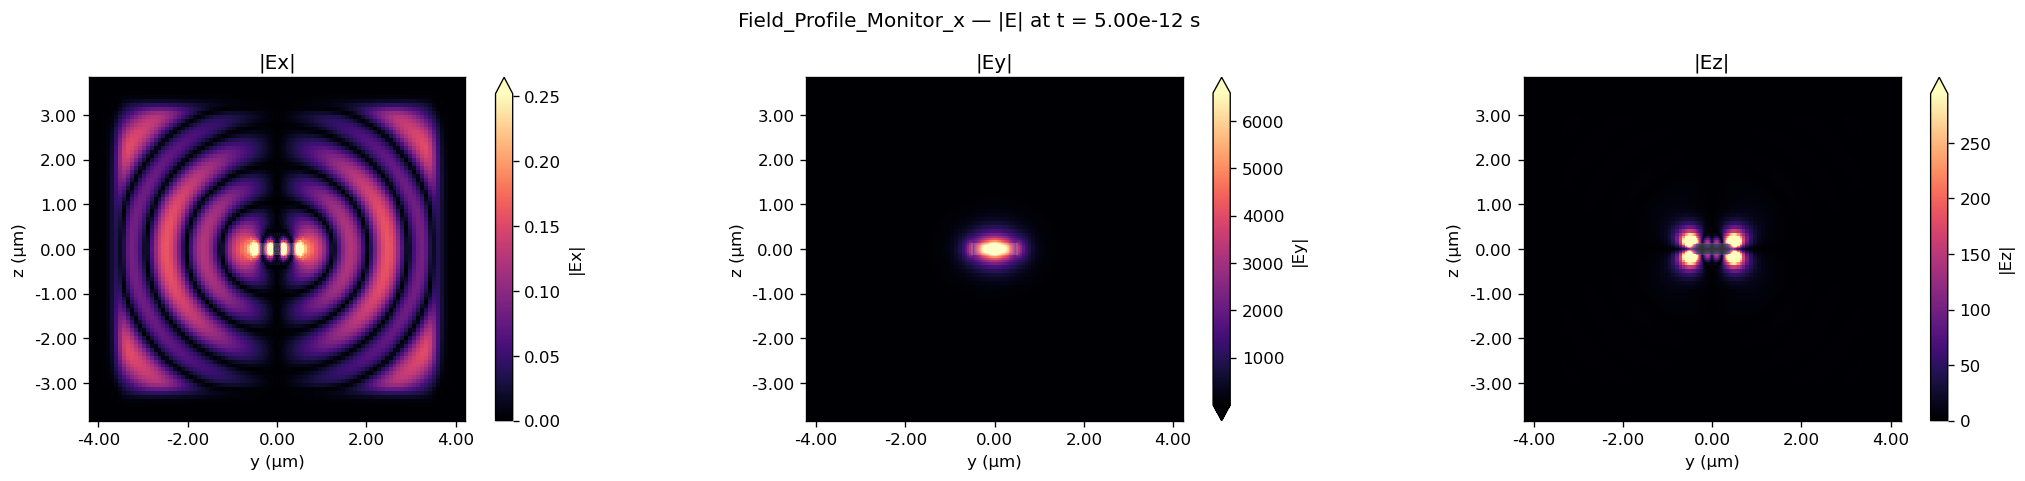

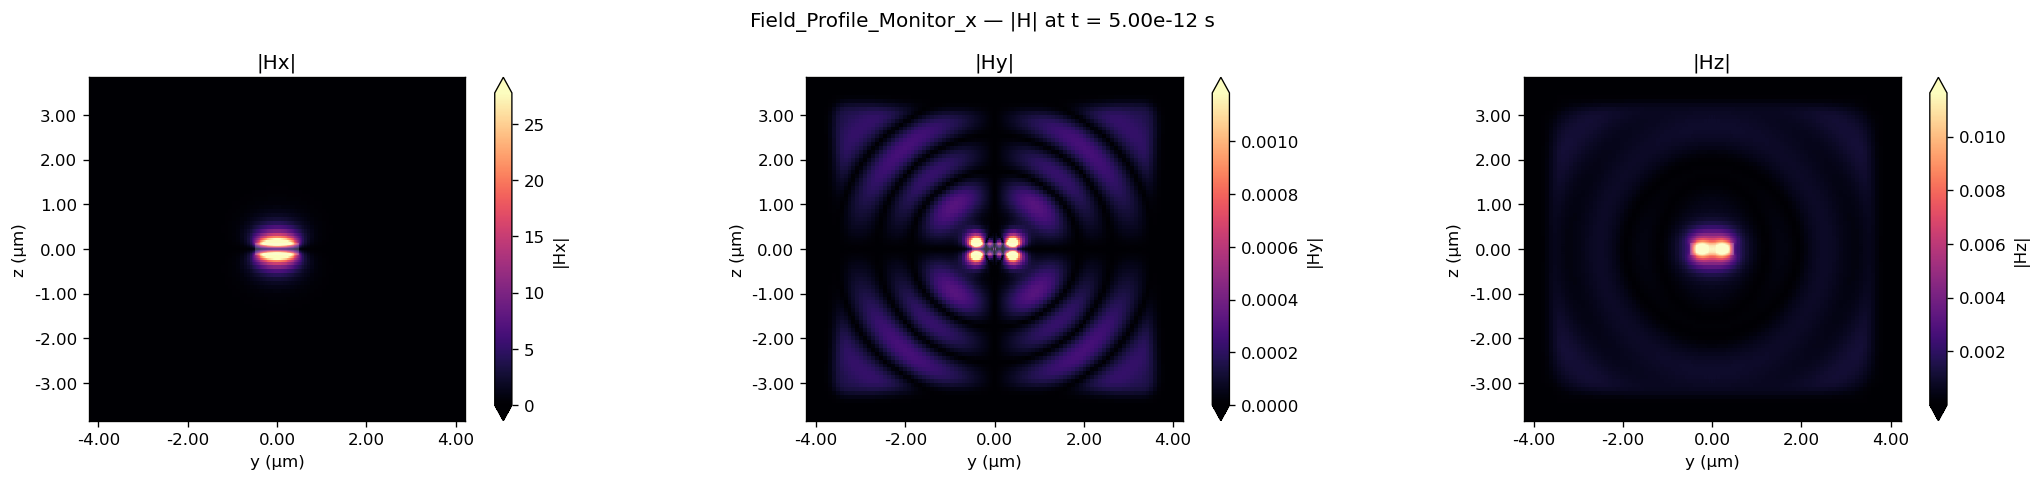

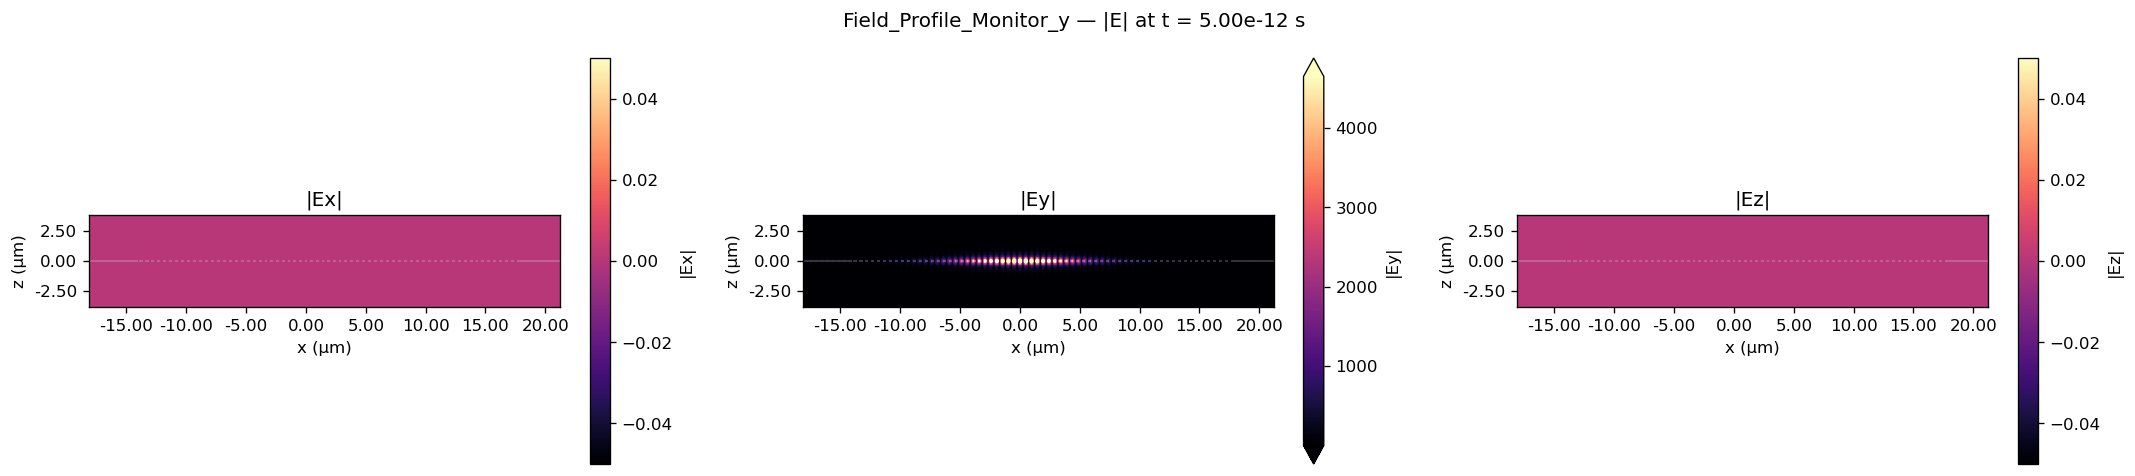

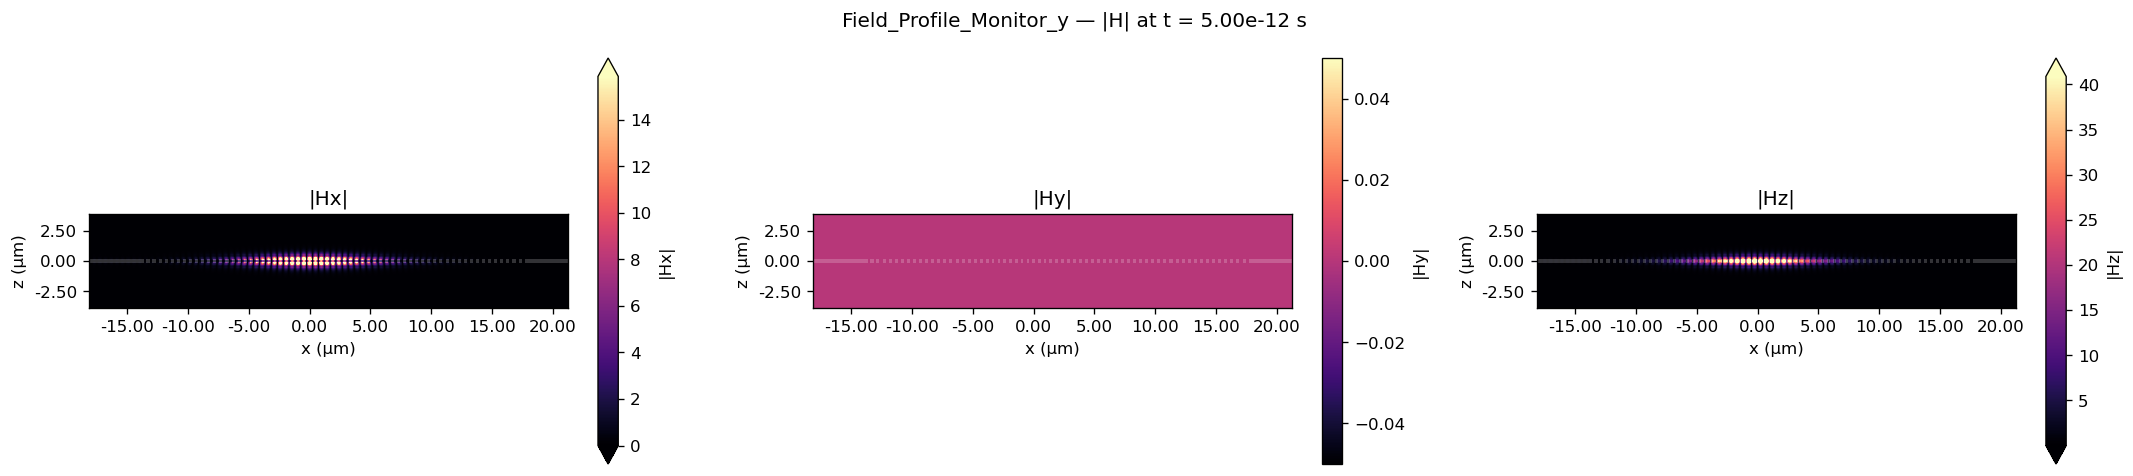

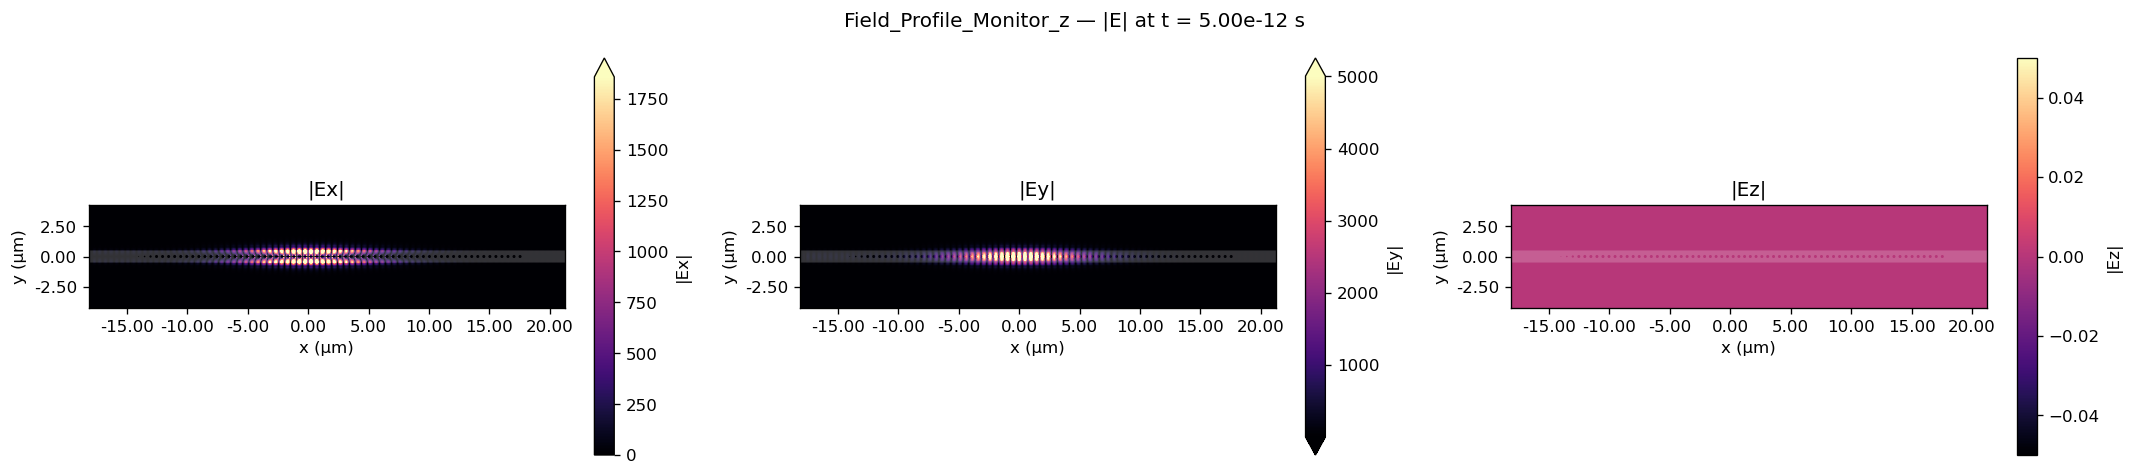

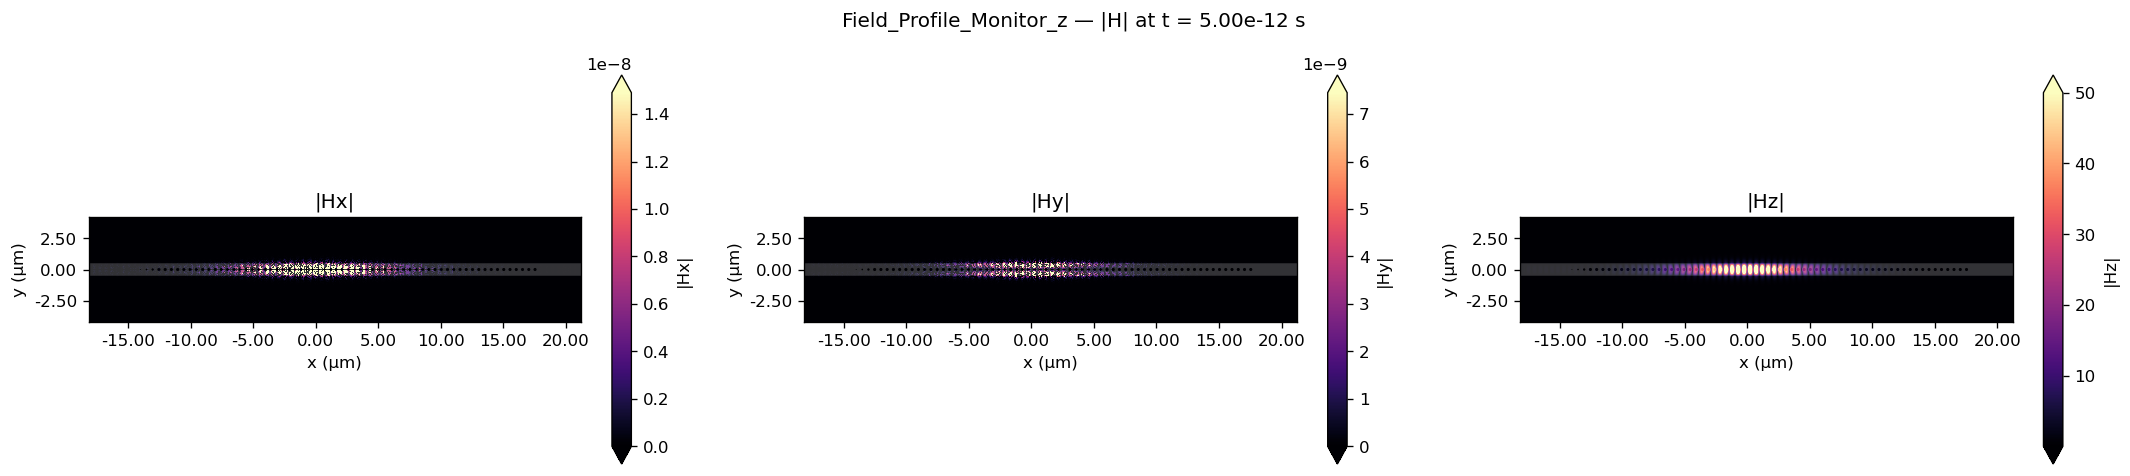

In [15]:
# --- Uncomment after running the simulation ---
cavity.simulation.plot_results()

### Mode Profile with Gaussian Fit

Extracts the 1D field profile along the beam axis and fits a Gaussian-modulated sinusoid. The fit not always work. I guess is due to the inital guesses for the parameters.

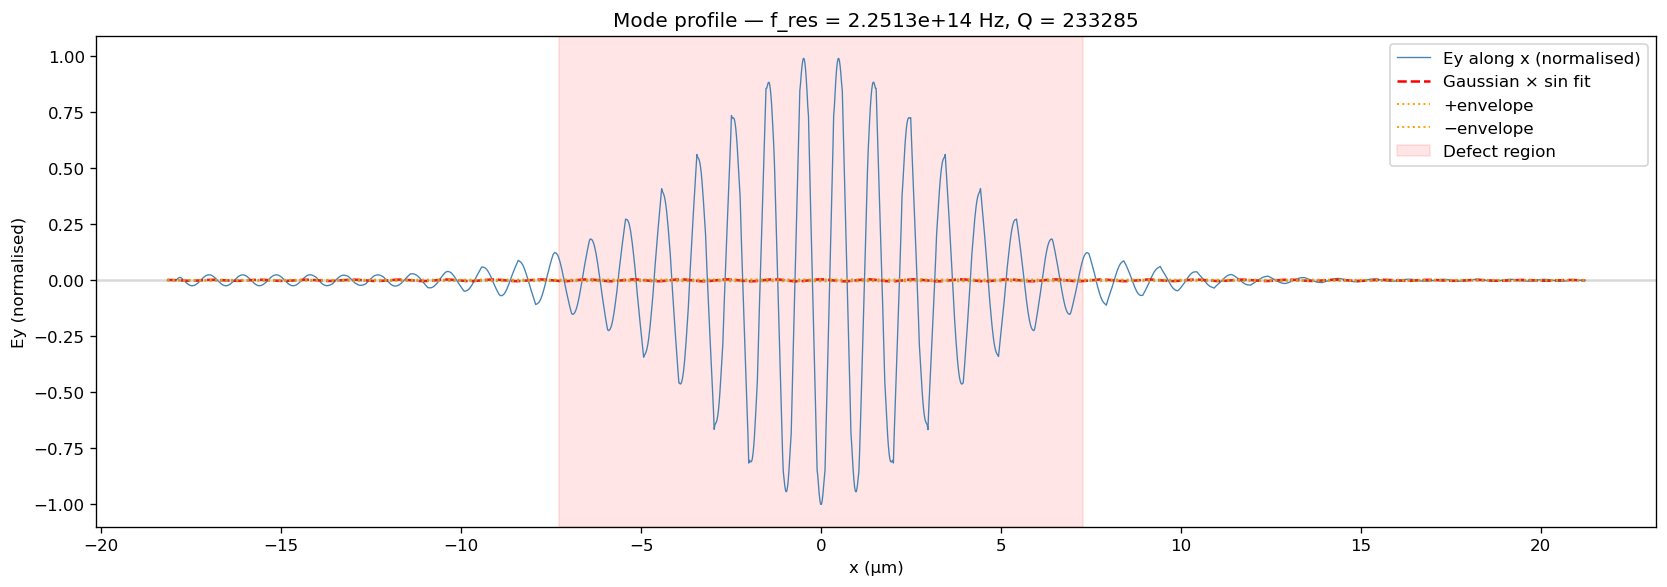

Fit: A=0.0043, σ=15.2181 µm, k=4.83 rad/µm, φ=1.590


In [18]:
# --- Uncomment after running the simulation ---
popt, pcov = cavity.simulation.plot_mode_along_beam()

### Polarization across cuts of the cavity

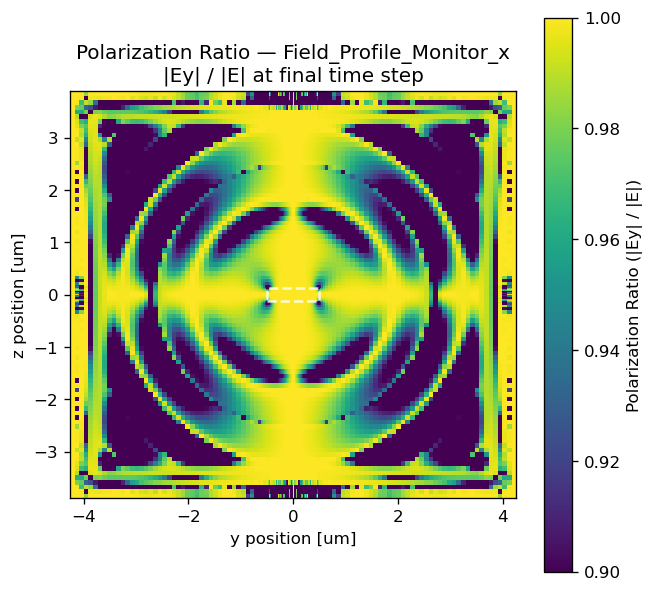

In [17]:
pol_map = cavity.simulation.polarization_profile(monitor_name="Field_Profile_Monitor_x", polarization_component="Ey", plot=True)

# You can analyze the coupling g and the cooperativity 

The cooperativity calculation is done with the values of kappa from the Q given by resonance analysis. Bu the coupling efficiency is done with the values of kappa from Q directional to be able to find kappa_out directional. 

It is important to give the value of the dipole moment for the transition we are interested in. 

It is also possible to find the cooperativity for a specific position. 

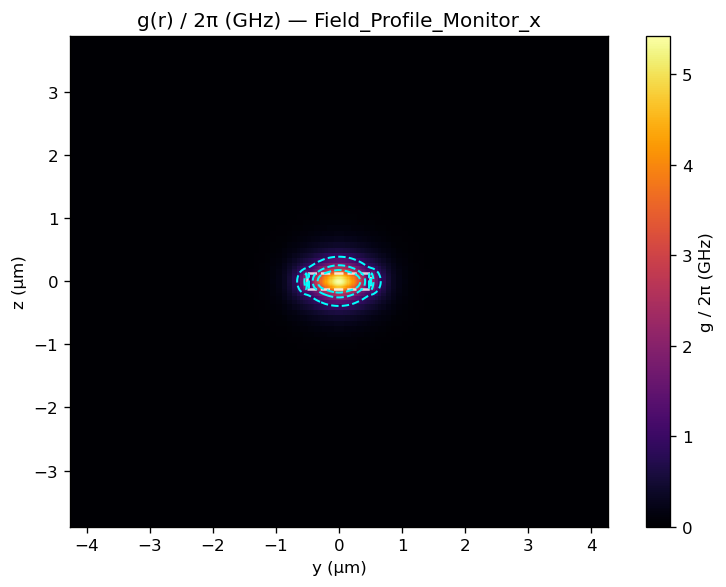

  g(r) / 2π = 0.9256 GHz
  κ_tot / 2π    = 0.9650 GHz
  κ_-x / 2π = 3.1397 GHz
  γ / 2π    = 1.2173 MHz
  C(r)      = 2917.26
  η(r)      = 89.64%  (fiber eff. 99.0%)


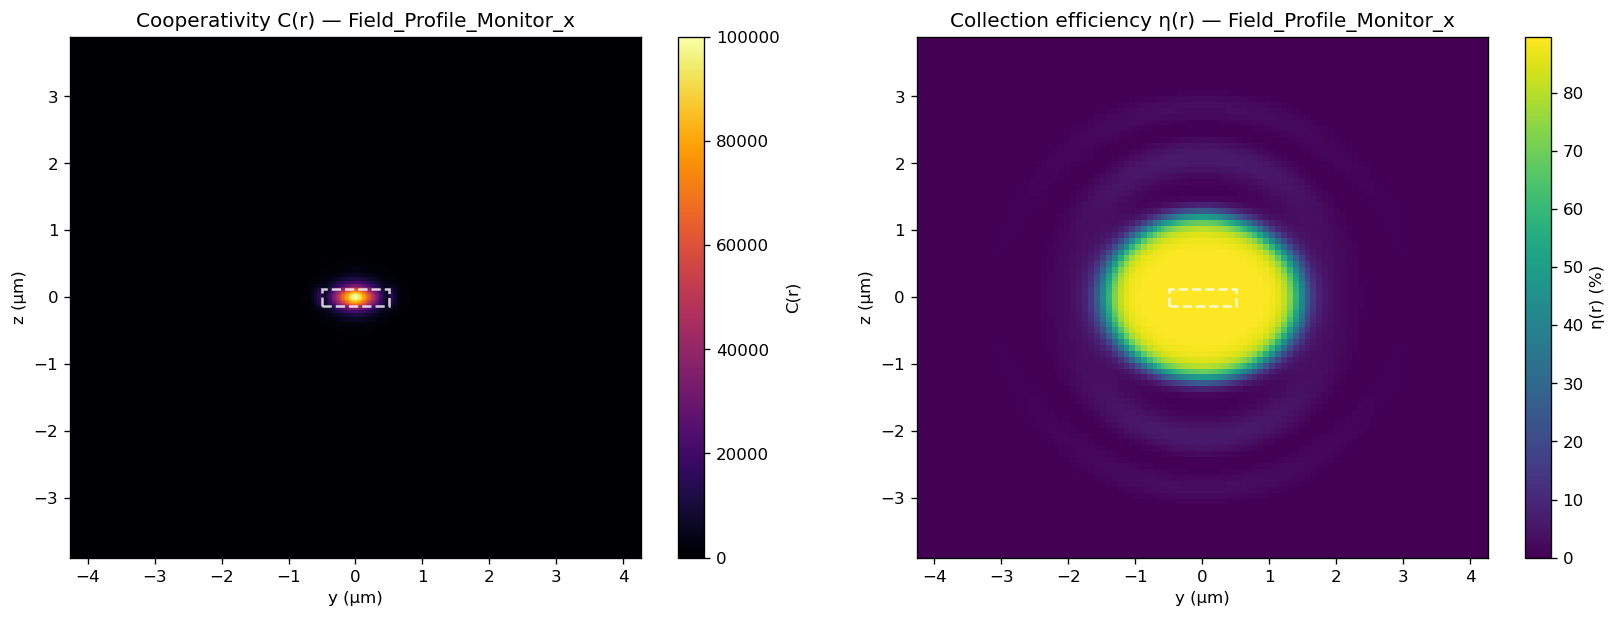

In [19]:
mu_reduced = 3.58e-29  # C·m, full D2 reduced matrix element
mu_cycling = np.sqrt(1/2) * mu_reduced  # ≈ 2.53e-29 C·m
g_map, g_max = cavity.simulation.coupling_g(dipole_moment=mu_cycling, monitor_name="Field_Profile_Monitor_x", polarization_component="Ey", plot=True, contour_ghz=[1,2,3])

C = cavity.simulation.cooperativity(
    dipole_moment=mu_cycling,
    position={"y": 0.0, "z": 0.4},
    channel="-x",  
    monitor_name="Field_Profile_Monitor_x", 
    polarization_component="Ey",
    plot=True,
)


### Field Animation

Creates an animated GIF of a field component on a 2D monitor over time.

GIF saved: cavity_tutorial/cavity_Ey_z.gif (60 frames, 15 fps, 120 dpi)


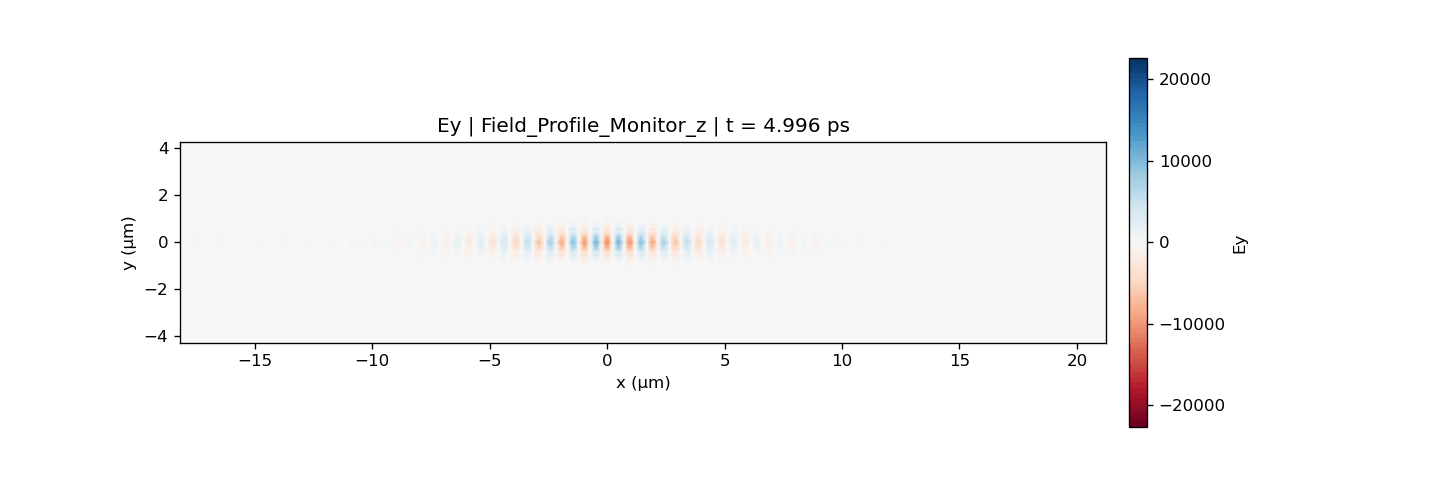

In [21]:
# --- Uncomment after running the simulation ---
cavity.simulation.animate_field(
    monitor_name="Field_Profile_Monitor_z",
    field_component="Ey",
    output_path=f'{directory}/cavity_Ey_z.gif',
    fps=15,
    dpi=120,
    n_frames=60,
)

from IPython.display import Image
Image(filename=f'{directory}/cavity_Ey_z.gif')

---
## Saving and Loading Cavities

Once the simulation is run there is automatically saved a json file with all the parameters of the tidy3d simulation. It is line 

self.sim.to_file(local_path)

in the function cavity.simulation.upload. Then once the simulation is run it is automatically saved in the hdf5 file. 

### Load from simulation HDF5

After running, the simulation data includes the cavity definition in its metadata. You can fully reconstruct the `Cavity` (with simulation data attached) from the HDF5 file.

You can call a function called from_saved_simulation_file both to create an instance of the cavity class or directly to create an instance of the cavity_simulation class. In the second case you have not created an instance of the cavity class so you won't be able to call methods of the cavity class. 

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from cavity import Cavity
from simulation import Cavity_simulation
from bandstructure_class import BandStructureSim

import tidy3d as td
C0 = td.constants.C_0

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

directory = "cavity_tutorial"
save_name = "cavity_tutorial_simulation"

# --- Uncomment if you have a completed simulation file ---
cavity_from_sim = Cavity.from_saved_simulation_file(f"{directory}/cavity_tutorial_simulation.hdf5")
cavity_from_sim.simulation.full_analysis()

=== Resonance Analysis ===
                     decay              Q     amplitude     phase     error  \
freq                                                                          
2.251255e+14  3.031709e+09  233285.083005  37305.135955 -2.635928  0.001665   

                    wl  
freq                    
2.251255e+14  1.331668  

Best resonance: f = 2.2513e+14 Hz, Q = 233285

=== Energy Density ===
Energy density computed.

=== Mode Volume [um³] ===
Mode volume: 1.4182 (λ[um]/n)³

=== Directional Q ===
Q_+x = 2.25 M
Q_-x = 0.07 M
Q_+y = 4.77 M
Q_-y = 4.77 M
Q_+z = 3.41 M
Q_-z = 3.41 M
Q_total = 0.06 M

=== Directional kappa ===
  κ_+x / 2π = 0.100 GHz
  κ_-x / 2π = 3.140 GHz
  κ_+y / 2π = 0.047 GHz
  κ_-y / 2π = 0.047 GHz
  κ_+z / 2π = 0.066 GHz
  κ_-z / 2π = 0.066 GHz
  κ_total / 2π = 3.466 GHz

=== Summary ===
  Q (resonance finder): 233285
  Kappa (total): 0.965 GHz
  Q (directional total): 0.06 M
  Mode volume: 1.4182 in units of (λ[um]/n)³
  Purcell factor estimate: 12500

---
## GDS Export with gdsfactory

If `gdsfactory` is installed, you can export the cavity layout to a GDS file for fabrication.

```bash
pip install gdsfactory
```

Component name: Unnamed_0
Ports: ['left', 'right']
GDS written: cavity_tutorial.gds


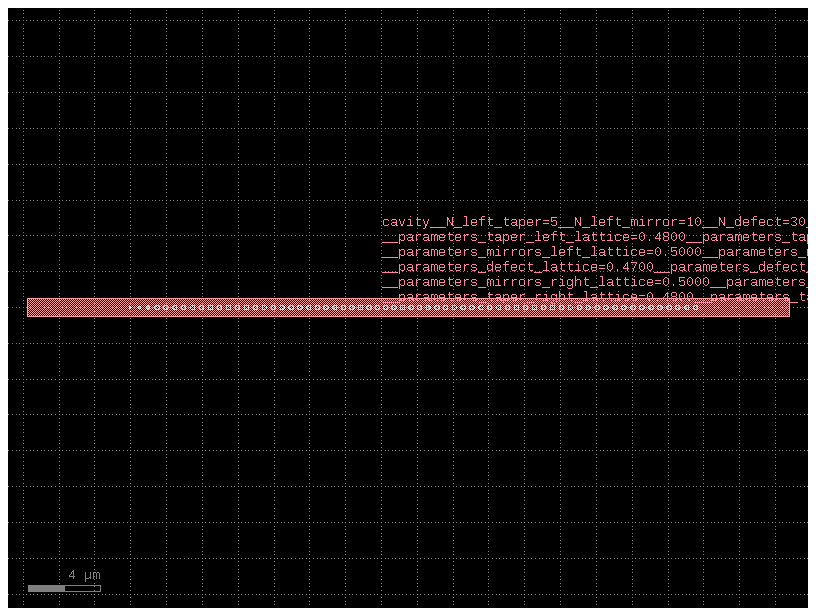

In [24]:
import gdsfactory as gf
gf.kcl.clear()
gf.gpdk.PDK.activate()

component = cavity.render_gdsfactory(
    layer=(1, 0),
    hole_layer=(2, 0),
    n_pts=128,
    waveguide_extension=5.0,
)
component.plot()
print(f"Component name: {component.name}")
print(f"Ports: {[p.name for p in component.ports]}")

# Write to GDS — use a unique top-cell name to avoid collisions on re-run
top = gf.Component("cavity_export")
top.add_ref(component)
top.write_gds(f"{directory}/cavity_tutorial.gds")
print("GDS written: cavity_tutorial.gds")


---
## Exploring Hole Geometries

The `hole_polygon_2d` function generates 2D polygons for different hole shapes. You can visualise them directly.

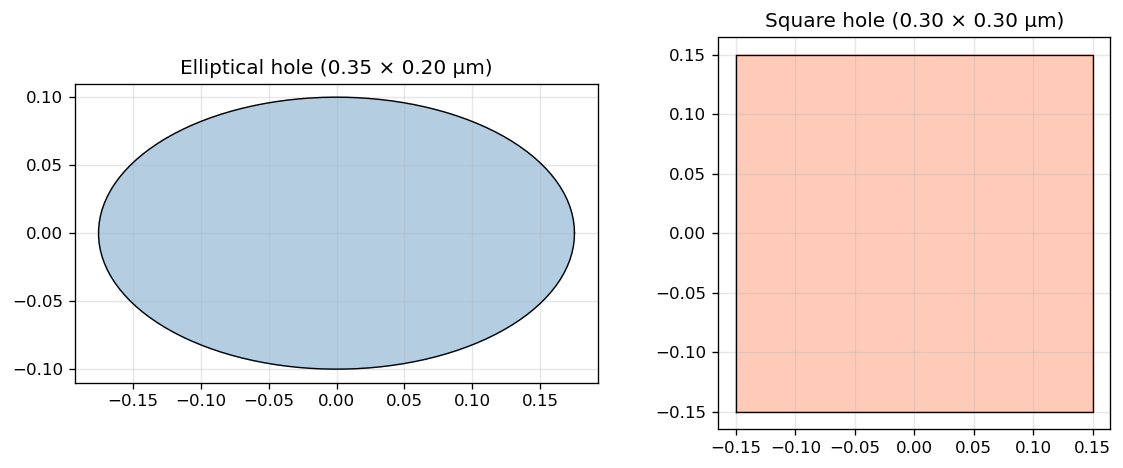

In [25]:
from hole import hole_polygon_2d

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Elliptical hole
poly_ellipse = hole_polygon_2d("ellipse", [0.35, 0.20], n_pts=128)
axes[0].fill(poly_ellipse[:, 0], poly_ellipse[:, 1], alpha=0.4, color='steelblue')
axes[0].plot(poly_ellipse[:, 0], poly_ellipse[:, 1], 'k-', linewidth=0.8)
axes[0].set_title('Elliptical hole (0.35 × 0.20 µm)')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# Square hole
poly_square = hole_polygon_2d("square", [0.30, 0.30])
axes[1].fill(poly_square[:, 0], poly_square[:, 1], alpha=0.4, color='coral')
axes[1].plot(poly_square[:, 0], poly_square[:, 1], 'k-', linewidth=0.8)
axes[1].set_title('Square hole (0.30 × 0.30 µm)')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Descriptive Cavity Name

The `get_name()` method generates a machine-readable identifier encoding all cell counts and parameters — useful for batch sweeps.

In [ ]:
print(cavity.get_name())

cavity__N_left_taper=8__N_left_mirror=15__N_defect=21__N_right_mirror=15__N_right_taper=8
__parameters_taper_left_lattice=0.4000__parameters_taper_left_hole_params=[0.1200,0.1200]
__parameters_mirrors_left_lattice=0.5400__parameters_mirrors_left_hole_params=[0.1800,0.1800]
__parameters_defect_lattice=0.4000__parameters_defect_hole_params=[0.1000,0.1000]
__parameters_mirrors_right_lattice=0.5400__parameters_mirrors_right_hole_params=[0.1800,0.1800]
__parameters_taper_right_lattice=0.4000__parameters_taper_right_hole_params=[0.1200,0.1200]
